In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#Connect with Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [ ]:
DATA_PATH = ('/content/drive/MyDrive/Dataset/ecommerce_retail.xlsx')

In [ ]:
SNAPSHOT_DATE = pd.Timestamp("2011-12-31")

In [ ]:
df_retail = pd.read_excel(DATA_PATH)

In [ ]:
# 2. LOAD & CLEAN DATA
df_retail.columns = df_retail.columns.str.strip()

In [ ]:
# Drop rows with missing CustomerID
df_retail = df_retail.dropna(subset=["CustomerID"])
df_retail["CustomerID"] = df_retail["CustomerID"].astype(int)

In [ ]:
 # Remove cancelled invoices
df_retail = df_retail[~df_retail["InvoiceNo"].astype(str).str.startswith("C")]

In [ ]:
# Keep only valid purchases
df_retail = df_retail[(df_retail["Quantity"] > 0) & df_retail["UnitPrice"] > 0]

In [ ]:
# Parse datetime
df_retail["InvoiceDate"] = pd.to_datetime(df_retail["InvoiceDate"],errors="coerce")
df_retail = df_retail.dropna(subset=["InvoiceDate"])

In [ ]:
# Create sales amount
df_retail["SalesAmount"] = (df_retail["Quantity"] * df_retail["UnitPrice"])

In [ ]:
df_retail

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [ ]:
df_retail.shape

(397884, 9)

In [ ]:
df_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


**# 2. EDA**
**văn bản in đậm**


## Sales by Country

In [ ]:
# =========================
# EDA 2. Sales by Country
# =========================
country_revenue_table = (
    df_retail.groupby("Country", as_index=False)["SalesAmount"]
    .sum()
    .sort_values("SalesAmount", ascending=False)
)

country_revenue_table["RevenueShare"] = (
    country_revenue_table["SalesAmount"] /
    country_revenue_table["SalesAmount"].sum()
)

In [ ]:
country_revenue_table.head(10)

,Country,SalesAmount,RevenueShare
35,United Kingdom,7308391.554,0.820116
23,Netherlands,285446.340,0.032032
10,EIRE,265545.900,0.029798
14,Germany,228867.140,0.025682
13,France,209024.050,0.023456
0,Australia,138521.310,0.015544
30,Spain,61577.110,0.006910
32,Switzerland,56443.950,0.006334
3,Belgium,41196.340,0.004623
31,Sweden,38378.330,0.004307


#3. Top countries by revenue

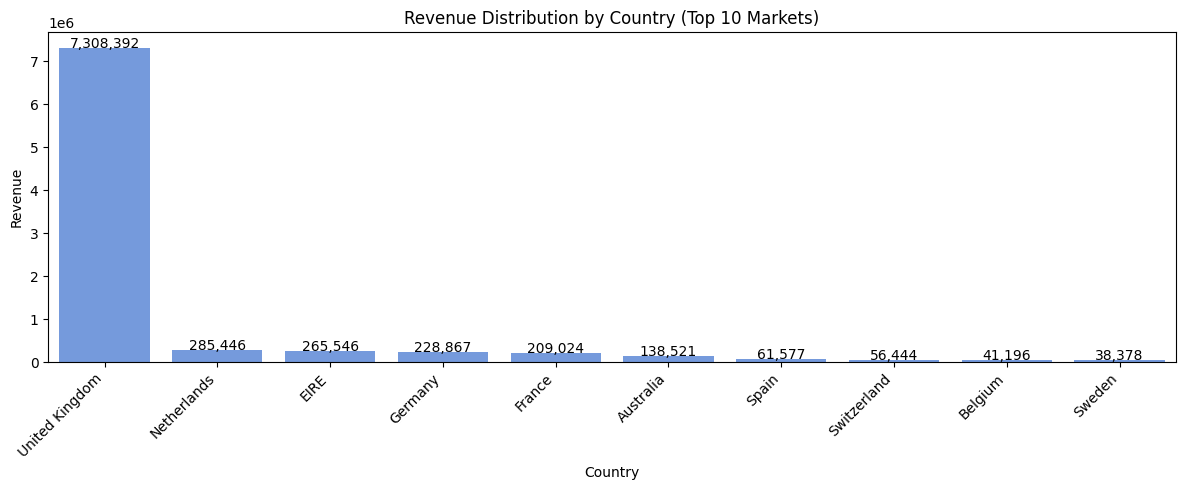

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=country_revenue_table.head(10),
    x="Country",
    y="SalesAmount",
    color="cornflowerblue"
)

plt.title("Revenue Distribution by Country (Top 10 Markets)")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

# add value labels
for p in plt.gca().patches:
    plt.text(
        p.get_x() + p.get_width()/2,
        p.get_height(),
        f'{p.get_height():,.0f}',
        ha='center'
    )

plt.tight_layout()
plt.show()

# EDA 4. Revenue share by country

In [ ]:
top_country_share_table = country_revenue_table.head(10).copy()
top_country_share_table["RevenueSharePct"] = top_country_share_table["RevenueShare"] * 100

top_country_share_table[["Country", "SalesAmount", "RevenueSharePct"]]

,Country,SalesAmount,RevenueSharePct
35,United Kingdom,7308391.554,82.011638
23,Netherlands,285446.340,3.203156
10,EIRE,265545.900,2.979842
14,Germany,228867.140,2.568249
13,France,209024.050,2.345578
0,Australia,138521.310,1.554427
30,Spain,61577.110,0.690992
32,Switzerland,56443.950,0.633390
3,Belgium,41196.340,0.462288
31,Sweden,38378.330,0.430665


# EDA 5. Transactions by country

In [ ]:
country_transactions= (
    df_retail
    .groupby("Country")["InvoiceNo"]
    .nunique()
    .reset_index()
)

country_transactions.columns = ["Country", "Transactions"]

country_transactions = country_transactions.sort_values(
    by="Transactions",
    ascending=False
)

country_transactions.head(10)

,Country,Transactions
35,United Kingdom,16646
14,Germany,457
13,France,389
10,EIRE,260
3,Belgium,98
23,Netherlands,94
30,Spain,90
26,Portugal,57
0,Australia,57
32,Switzerland,51


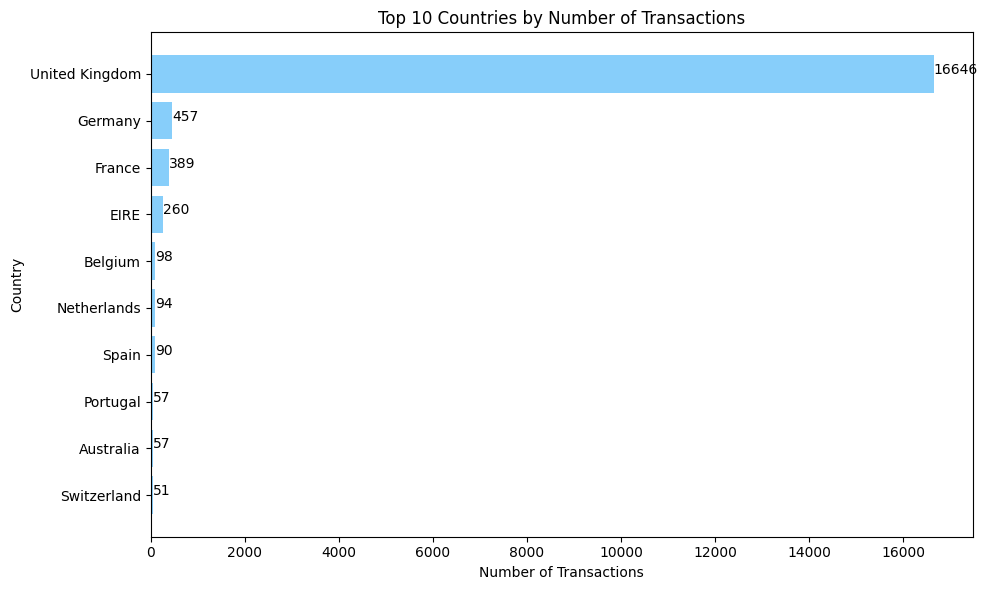

In [ ]:
top10_transactions = country_transactions.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10_transactions["Country"],
    top10_transactions["Transactions"],
    color = 'lightskyblue'
)

plt.xlabel("Number of Transactions")
plt.ylabel("Country")
plt.title("Top 10 Countries by Number of Transactions")

plt.gca().invert_yaxis()

for index, value in enumerate(top10_transactions["Transactions"]):
    plt.text(value, index, str(value))

plt.tight_layout()
plt.show()

# FILTER UK MARKET

In [ ]:
df_uk_retail = df_retail[
    df_retail["Country"] == "United Kingdom"
].copy()

print("UK dataset shape:", df_uk_retail.shape)
print("UK unique customers:", df_uk_retail["CustomerID"].nunique())
print("UK unique invoices:", df_uk_retail["InvoiceNo"].nunique())

df_uk_retail.head()

UK dataset shape: (354321, 9)
UK unique customers: 3920
UK unique invoices: 16646


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


# UK EDA 1. Monthly revenue trend

In [ ]:
df_uk_retail["YearMonth"] = df_uk_retail["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue_uk_table = (
    df_uk_retail.groupby("YearMonth", as_index=False)["SalesAmount"]
    .sum()
)



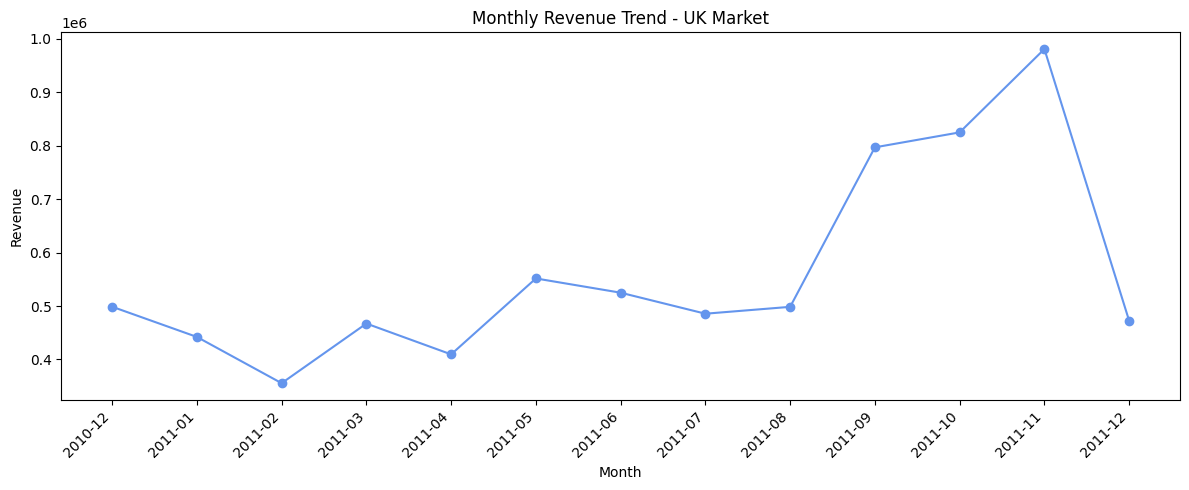

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue_uk_table["YearMonth"],
    monthly_revenue_uk_table["SalesAmount"],
    marker="o",
    color="cornflowerblue"
)

plt.title("Monthly Revenue Trend - UK Market")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# UK EDA 2. Basket size distribution



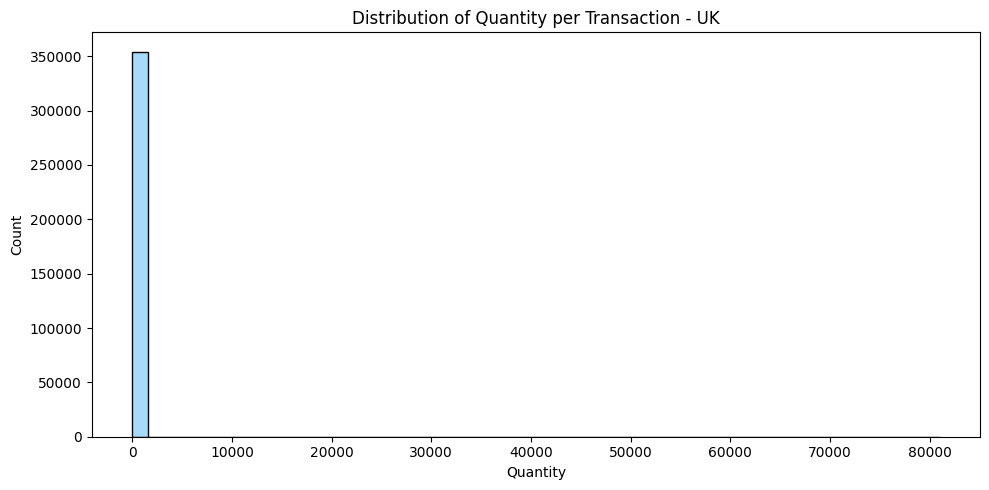

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_uk_retail,
    x="Quantity",
    bins=50,
    color="lightskyblue"
)

plt.title("Distribution of Quantity per Transaction - UK")
plt.xlabel("Quantity")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

 UK EDA 3. Top selling products

In [ ]:
top_products_uk_table = (
    df_uk_retail.groupby("Description", as_index=False)["Quantity"]
    .sum()
    .sort_values("Quantity", ascending=False)
    .head(10)
)

top_products_uk_table



,Description,Quantity
2298,"PAPER CRAFT , LITTLE BIRDIE",80995
1975,MEDIUM CERAMIC TOP STORAGE JAR,76919
3753,WORLD WAR 2 GLIDERS ASSTD DESIGNS,49182
1747,JUMBO BAG RED RETROSPOT,41981
3666,WHITE HANGING HEART T-LIGHT HOLDER,34648
213,ASSORTED COLOUR BIRD ORNAMENT,32727
2574,POPCORN HOLDER,28935
2214,PACK OF 12 LONDON TISSUES,24337
535,BROCADE RING PURSE,22711
2248,PACK OF 72 RETROSPOT CAKE CASES,22465


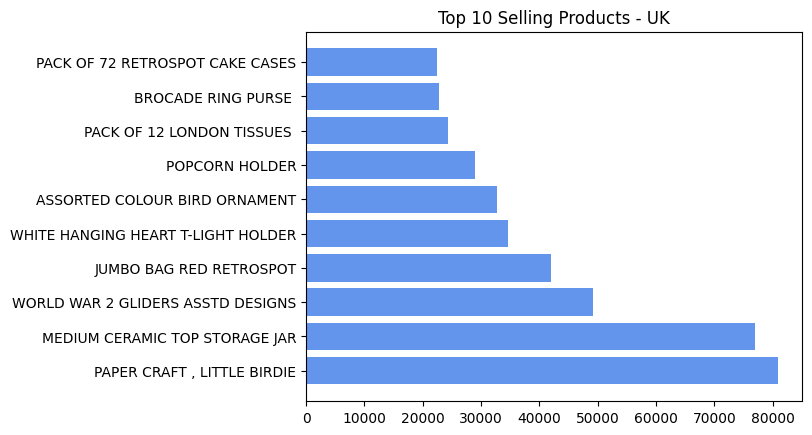

In [ ]:
plt.barh(
    top_products_uk_table["Description"],
    top_products_uk_table["Quantity"],
    color="cornflowerblue"
)
plt.title("Top 10 Selling Products - UK")
plt.show()

# BUILD RFM TABLE - UK

In [ ]:
from datetime import datetime

# Snapshot date
SNAPSHOT_DATE = datetime(2011, 12, 31)

def build_rfm_table(df_market, snapshot_date):

    rfm_market_table = (
        df_market
        .groupby("CustomerID", as_index=False)
        .agg(
            LastPurchaseDate=("InvoiceDate", "max"),
            Frequency=("InvoiceNo", "nunique"),
            Monetary=("SalesAmount", "sum")
        )
    )

    # Calculate Recency
    rfm_market_table["Recency"] = (
        snapshot_date - rfm_market_table["LastPurchaseDate"]
    ).dt.days

    return rfm_market_table


# Build UK RFM table
rfm_uk_table = build_rfm_table(df_uk_retail, SNAPSHOT_DATE)

rfm_uk_table.head()

,CustomerID,LastPurchaseDate,Frequency,Monetary,Recency
0,12346,2011-01-18 10:01:00,1,77183.60,346
1,12747,2011-12-07 14:34:00,11,4196.01,23
2,12748,2011-12-09 12:20:00,209,33719.73,21
3,12749,2011-12-06 09:56:00,5,4090.88,24
4,12820,2011-12-06 15:12:00,4,942.34,24


Create RFM Scores

In [ ]:
# Recency: smaller is better → higher score
rfm_uk_table["R_score"] = pd.qcut(
    rfm_uk_table["Recency"],
    q=5,
    labels=[5,4,3,2,1]
).astype(int)

# Frequency: larger is better → higher score
rfm_uk_table["F_score"] = pd.qcut(
    rfm_uk_table["Frequency"].rank(method="first"),
    q=5,
    labels=[1,2,3,4,5]
).astype(int)

# Monetary: larger is better → higher score
rfm_uk_table["M_score"] = pd.qcut(
    rfm_uk_table["Monetary"],
    q=5,
    labels=[1,2,3,4,5]
).astype(int)


# Create RFM code
rfm_uk_table["RFM_Code"] = (
    rfm_uk_table["R_score"].astype(str)
    + rfm_uk_table["F_score"].astype(str)
    + rfm_uk_table["M_score"].astype(str)
)

In [ ]:
rfm_uk_table

,CustomerID,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_Code,Segment,TotalOrders,TotalRevenue,AvgOrderValue,AvgItems,AvgSKU,GroupSegment
0,12346,2011-01-18 10:01:00,1,77183.60,346,1,1,5,115,Hibernating,1,77183.60,77183.600000,74215.000000,1.000000,Inactive & Lost
1,12747,2011-12-07 14:34:00,11,4196.01,23,5,5,5,555,Champions,11,4196.01,381.455455,115.909091,9.363636,Loyal & High Value
2,12748,2011-12-09 12:20:00,209,33719.73,21,5,5,5,555,Champions,209,33719.73,161.338421,123.191388,20.497608,Loyal & High Value
3,12749,2011-12-06 09:56:00,5,4090.88,24,5,4,5,545,Champions,5,4090.88,818.176000,294.200000,39.800000,Loyal & High Value
4,12820,2011-12-06 15:12:00,4,942.34,24,5,4,4,544,Champions,4,942.34,235.585000,180.500000,14.750000,Loyal & High Value
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3915,18280,2011-03-07 09:52:00,1,180.60,298,1,2,1,121,Hibernating,1,180.60,180.600000,45.000000,10.000000,Inactive & Lost
3916,18281,2011-06-12 10:53:00,1,80.82,201,1,2,1,121,Hibernating,1,80.82,80.820000,54.000000,7.000000,Inactive & Lost
3917,18282,2011-12-02 11:43:00,2,178.05,28,5,3,1,531,Potential Loyalists,2,178.05,89.025000,51.500000,6.000000,New & Potential
3918,18283,2011-12-06 12:02:00,16,2094.88,24,5,5,5,555,Champions,16,2094.88,130.930000,87.312500,43.062500,Loyal & High Value


In [ ]:
# SEGMENT MAPPING

def assign_rfm_segment(row):

    r = row["R_score"]
    f = row["F_score"]

    if (r >= 4) and (f >= 4):
        return "Champions"

    elif (r >= 3) and (f >= 4):
        return "Loyal Customers"

    elif (r >= 4) and (f >= 2):
        return "Potential Loyalists"

    elif (r == 5) and (f == 1):
        return "New Customers"

    elif (r == 4) and (f == 1):
        return "Promising"

    elif (r == 3) and (f >= 2):
        return "Need Attention"

    elif (r == 2) and (f <= 2):
        return "About To Sleep"

    elif (r <= 2) and (f >= 3):
        return "At Risk"

    elif (r == 1) and (f >= 4):
        return "Can't Lose Them"

    elif (r <= 2) and (f <= 2):
        return "Hibernating"

    else:
        return "Lost"


rfm_uk_table["Segment"] = rfm_uk_table.apply(assign_rfm_segment, axis=1)

In [ ]:
rfm_uk_table["Segment"] = rfm_uk_table.apply(assign_rfm_segment, axis=1)

Set Segment Order

In [ ]:
segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "New Customers",
    "Promising",
    "Need Attention",
    "About To Sleep",
    "At Risk",
    "Can't Lose Them",
    "Hibernating",
    "Lost"
]

rfm_uk_table["Segment"] = pd.Categorical(
    rfm_uk_table["Segment"],
    categories=segment_order,
    ordered=True
)

Final RFM Table

In [ ]:
rfm_uk_table[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "R_score",
        "F_score",
        "M_score",
        "RFM_Code",
        "Segment"
    ]
].head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Code,Segment
0,12346,346,1,77183.60,1,1,5,115,Hibernating
1,12747,23,11,4196.01,5,5,5,555,Champions
2,12748,21,209,33719.73,5,5,5,555,Champions
3,12749,24,5,4090.88,5,4,5,545,Champions
4,12820,24,4,942.34,5,4,4,544,Champions


In [ ]:
# =========================
# ORDER-LEVEL / CUSTOMER-LEVEL BEHAVIOR
# =========================
order_level_uk_table = (
    df_uk_retail.groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        OrderValue=("SalesAmount", "sum"),
        Items=("Quantity", "sum"),
        SKU_Count=("StockCode", "nunique")
    )
)

customer_behavior_uk_table = (
    order_level_uk_table.groupby("CustomerID", as_index=False)
    .agg(
        TotalOrders=("InvoiceNo", "nunique"),
        TotalRevenue=("OrderValue", "sum"),
        AvgOrderValue=("OrderValue", "mean"),
        AvgItems=("Items", "mean"),
        AvgSKU=("SKU_Count", "mean")
    )
)

rfm_uk_table = rfm_uk_table.merge(
    customer_behavior_uk_table,
    on="CustomerID",
    how="left"
)

rfm_uk_table.head()

,CustomerID,LastPurchaseDate,Frequency,Monetary,Recency,R_score,F_score,M_score,RFM_Code,Segment,TotalOrders,TotalRevenue,AvgOrderValue,AvgItems,AvgSKU
0,12346,2011-01-18 10:01:00,1,77183.60,346,1,1,5,115,Hibernating,1,77183.60,77183.600000,74215.000000,1.000000
1,12747,2011-12-07 14:34:00,11,4196.01,23,5,5,5,555,Champions,11,4196.01,381.455455,115.909091,9.363636
2,12748,2011-12-09 12:20:00,209,33719.73,21,5,5,5,555,Champions,209,33719.73,161.338421,123.191388,20.497608
3,12749,2011-12-06 09:56:00,5,4090.88,24,5,4,5,545,Champions,5,4090.88,818.176000,294.200000,39.800000
4,12820,2011-12-06 15:12:00,4,942.34,24,5,4,4,544,Champions,4,942.34,235.585000,180.500000,14.750000


#Visualization

In [ ]:
segment_order_desc = (
    rfm_uk_table["Segment"]
    .value_counts()
    .index
)

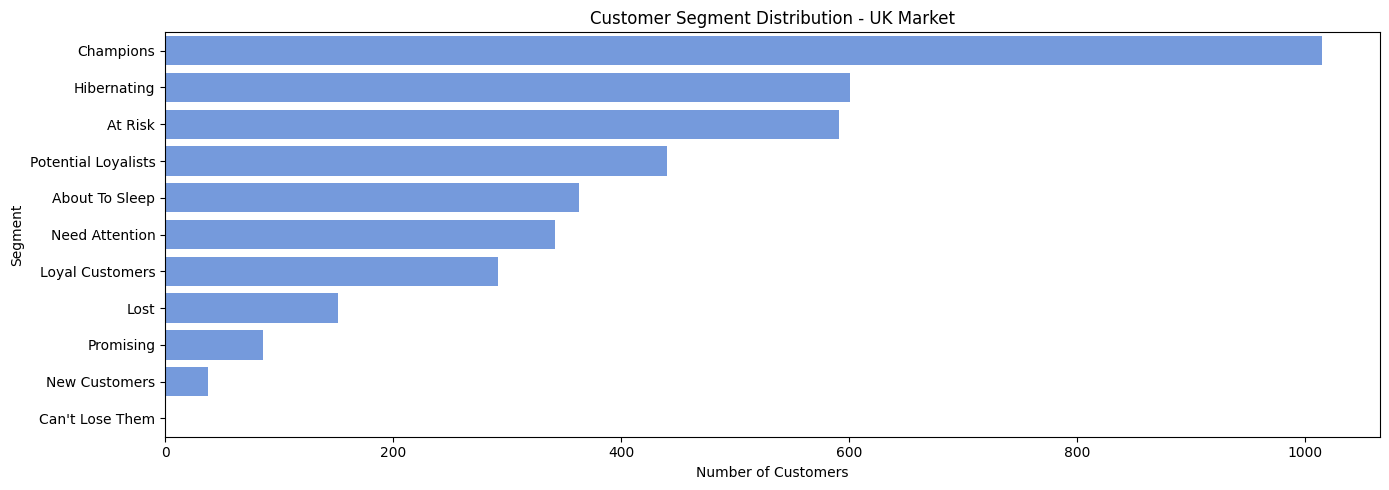

In [ ]:
plt.figure(figsize=(14,5))

sns.countplot(
    data=rfm_uk_table,
    y="Segment",
    order=segment_order_desc,
    color="cornflowerblue"
)

plt.title("Customer Segment Distribution - UK Market")
plt.ylabel("Segment")
plt.xlabel("Number of Customers")

plt.tight_layout()
plt.show()

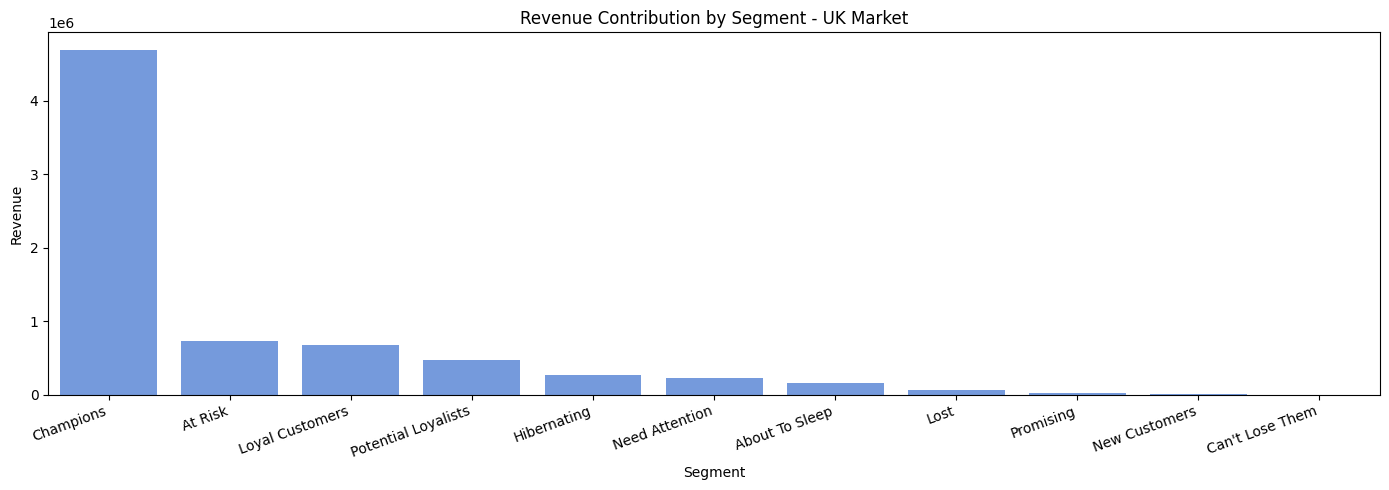

In [ ]:
segment_revenue_uk_table = (
    rfm_uk_table.groupby("Segment", observed=False, as_index=False)["TotalRevenue"]
    .sum()
    .sort_values("TotalRevenue", ascending=False)
)

plt.figure(figsize=(14, 5))

sns.barplot(
    data=segment_revenue_uk_table,
    x="Segment",
    y="TotalRevenue",
    order=segment_revenue_uk_table["Segment"],
    color= 'cornflowerblue'
)

plt.title("Revenue Contribution by Segment - UK Market")
plt.xlabel("Segment")
plt.ylabel("Revenue")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

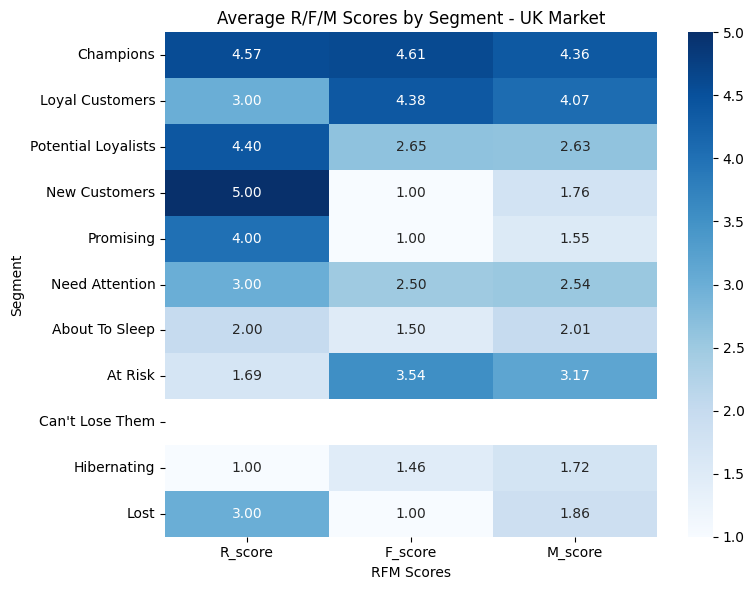

In [ ]:
heatmap_uk_table = (
    rfm_uk_table.groupby("Segment", observed=False)[["R_score", "F_score", "M_score"]]
    .mean()
)

plt.figure(figsize=(8, max(5, int(0.55 * len(heatmap_uk_table)))))

sns.heatmap(
    heatmap_uk_table,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Average R/F/M Scores by Segment - UK Market")
plt.xlabel("RFM Scores")
plt.ylabel("Segment")
plt.tight_layout()
plt.show()

In [ ]:
group_segment_map = {
    "Champions": "Loyal & High Value",
    "Loyal Customers": "Loyal & High Value",

    "Potential Loyalists": "New & Potential",
    "Promising": "New & Potential",
    "New Customers": "New & Potential",

    "At Risk": "High Risk Customers",
    "Can't Lose Them": "High Risk Customers",

    "About To Sleep": "Inactive & Lost",
    "Hibernating": "Inactive & Lost",
    "Lost": "Inactive & Lost",
    "Need Attention": "Inactive & Lost"
}

rfm_uk_table["GroupSegment"] = rfm_uk_table["Segment"].astype(str).map(group_segment_map)

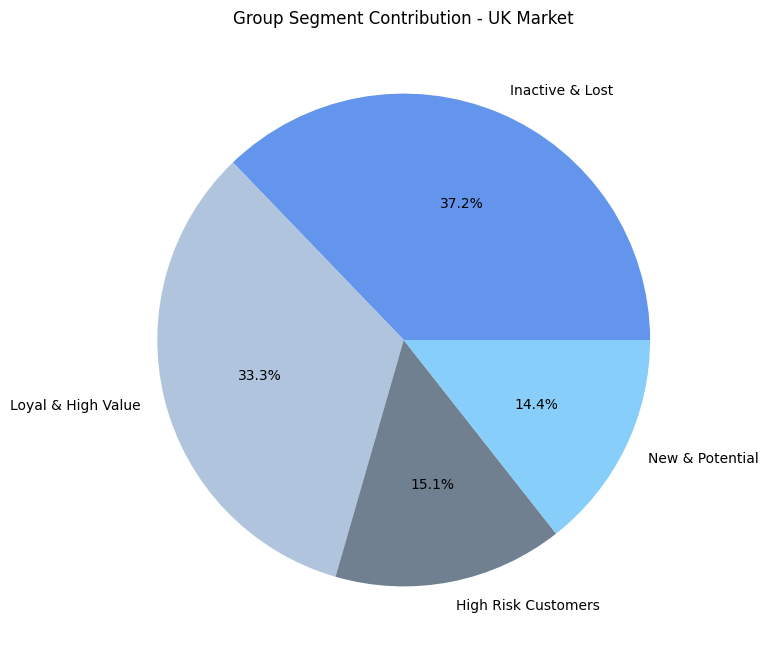

In [ ]:
group_segment_counts_uk = rfm_uk_table["GroupSegment"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    group_segment_counts_uk,
    labels=group_segment_counts_uk.index,
    autopct="%1.1f%%",
    colors=["cornflowerblue", "lightsteelblue", "slategrey", "lightskyblue"]
)

plt.title("Group Segment Contribution - UK Market")
plt.show()

In [ ]:
df_uk_retail["Month"] = df_uk_retail["InvoiceDate"].dt.to_period("M").astype(str)

In [ ]:
df_uk_segment = df_uk_retail.merge(
    rfm_uk_table[["CustomerID","GroupSegment"]],
    on="CustomerID",
    how="left"
)

In [ ]:
df_uk_segment = df_uk_retail.merge(
    rfm_uk_table[["CustomerID","GroupSegment"]],
    on="CustomerID",
    how="left"
)

In [ ]:
segment_month_table = (
    df_uk_segment
    .groupby(["Month", "GroupSegment"], as_index=False)
    .agg(Customers=("CustomerID", "nunique"))
)

In [ ]:
segment_month_pivot = segment_month_table.pivot(
    index="Month",
    columns="GroupSegment",
    values="Customers"
).fillna(0)

In [ ]:
segment_month_pivot.head()

GroupSegment,High Risk Customers,Inactive & Lost,Loyal & High Value,New & Potential
Month,,,,
2010-12,156.0,137.0,481.0,41.0
2011-01,126.0,97.0,410.0,14.0
2011-02,137.0,117.0,411.0,14.0
2011-03,189.0,156.0,511.0,24.0
2011-04,158.0,122.0,481.0,23.0


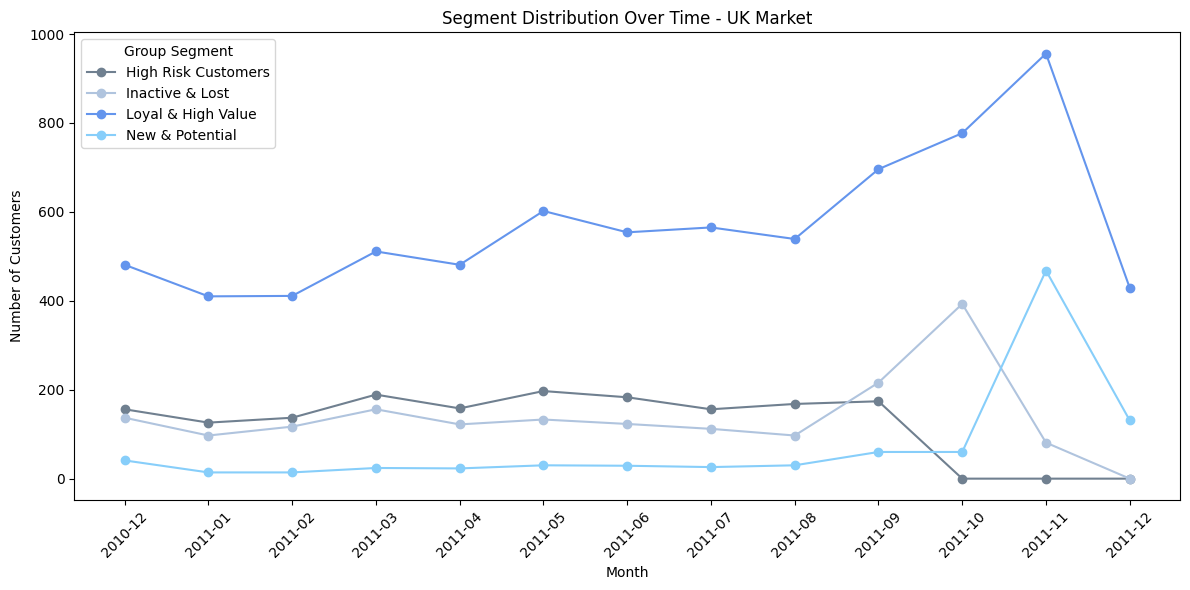

In [ ]:
colors = ['slategrey', 'lightsteelblue', 'cornflowerblue','lightskyblue']

plt.figure(figsize=(12,6))

for i, column in enumerate(segment_month_pivot.columns):
    plt.plot(
        segment_month_pivot.index,
        segment_month_pivot[column],
        marker='o',
        label=column,
        color=colors[i % len(colors)]
    )

plt.title("Segment Distribution Over Time - UK Market")
plt.xlabel("Month")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.legend(title="Group Segment")

plt.tight_layout()
plt.show()

In [ ]:
monthly_rfm_table = (
    df_uk_segment
    .groupby(["Month","GroupSegment"], as_index=False)
    .agg(
        Recency=("InvoiceDate", lambda x: (x.max() - x.min()).days),
        Frequency=("InvoiceNo","nunique"),
        Monetary=("SalesAmount","sum")
    )
)

In [ ]:
monthly_rfm_table = (
    df_uk_segment
    .groupby(["Month","GroupSegment"], as_index=False)
    .agg(
        Recency=("InvoiceDate", lambda x: (x.max() - x.min()).days),
        Frequency=("InvoiceNo","nunique"),
        Monetary=("SalesAmount","sum")
    )
)

In [ ]:
recency_pivot = monthly_rfm_table.pivot(
    index="Month",
    columns="GroupSegment",
    values="Recency"
).fillna(0)

frequency_pivot = monthly_rfm_table.pivot(
    index="Month",
    columns="GroupSegment",
    values="Frequency"
).fillna(0)

monetary_pivot = monthly_rfm_table.pivot(
    index="Month",
    columns="GroupSegment",
    values="Monetary"
).fillna(0)

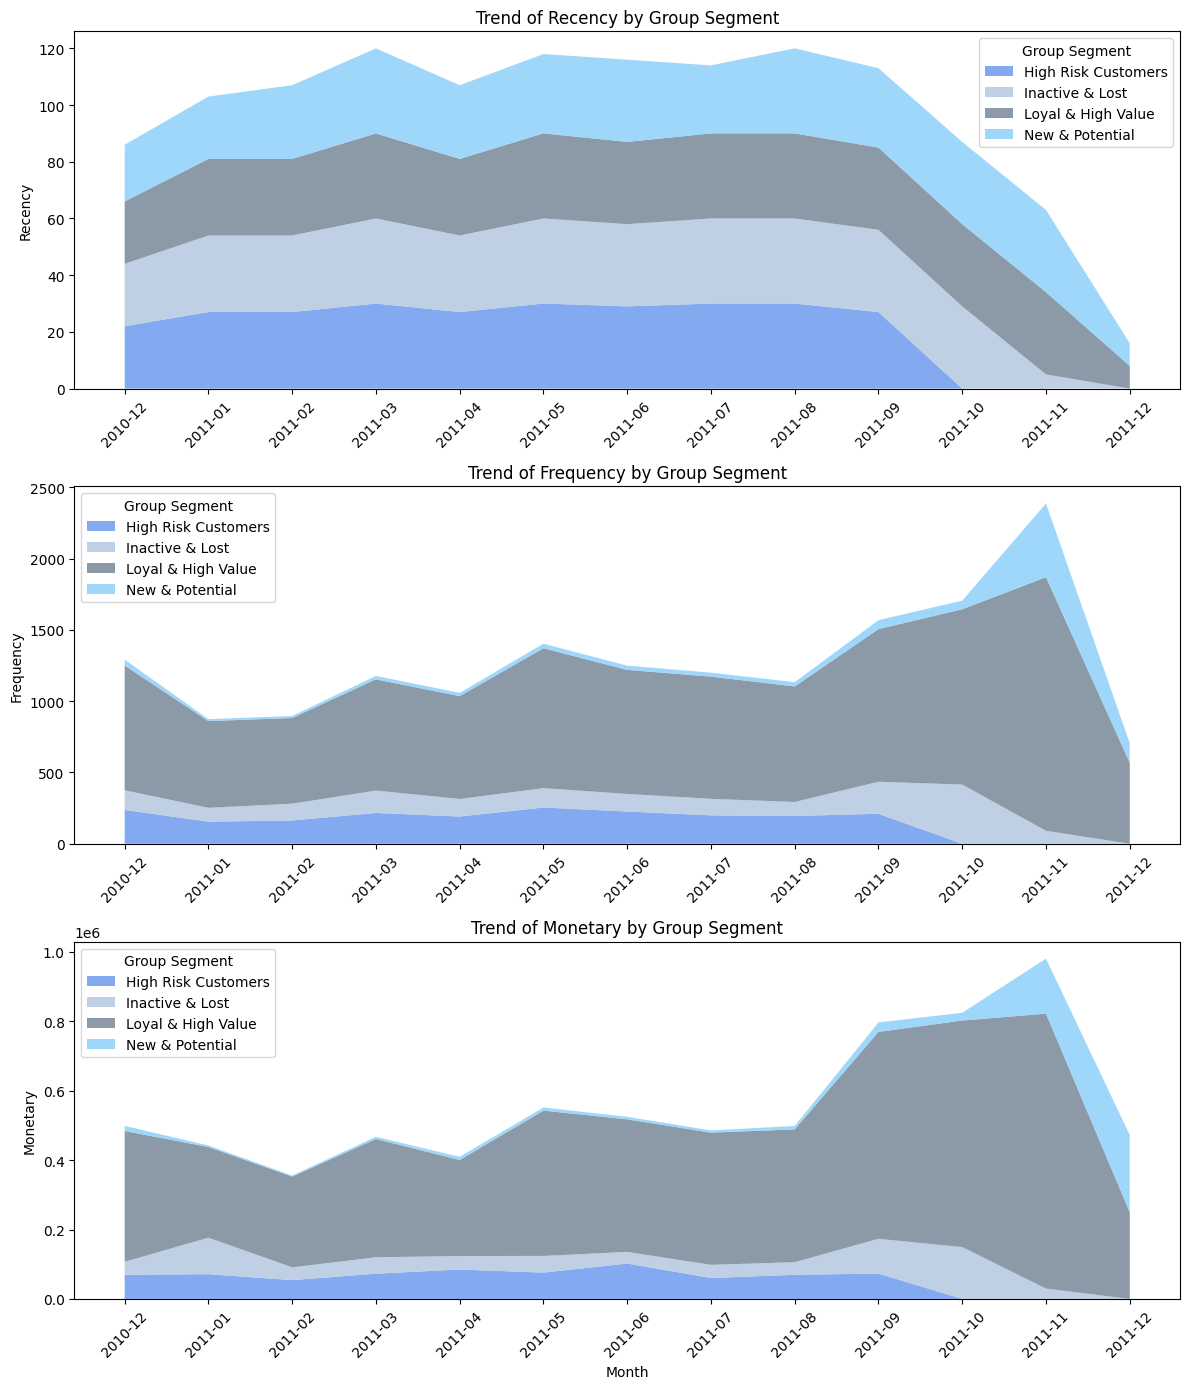

In [ ]:
colors = [
    "cornflowerblue",
    "lightsteelblue",
    "slategrey",
    "lightskyblue"
]

fig, axes = plt.subplots(3,1, figsize=(12,14))

# RECENCY
axes[0].stackplot(
    recency_pivot.index,
    recency_pivot.T,
    labels=recency_pivot.columns,
    colors=colors,
    alpha=0.8
)

axes[0].set_title("Trend of Recency by Group Segment")
axes[0].set_ylabel("Recency")
axes[0].legend(title="Group Segment")

# FREQUENCY
axes[1].stackplot(
    frequency_pivot.index,
    frequency_pivot.T,
    labels=frequency_pivot.columns,
    colors=colors,
    alpha=0.8
)

axes[1].set_title("Trend of Frequency by Group Segment")
axes[1].set_ylabel("Frequency")
axes[1].legend(title="Group Segment")

# MONETARY
axes[2].stackplot(
    monetary_pivot.index,
    monetary_pivot.T,
    labels=monetary_pivot.columns,
    colors=colors,
    alpha=0.8
)

axes[2].set_title("Trend of Monetary by Group Segment")
axes[2].set_ylabel("Monetary")
axes[2].set_xlabel("Month")
axes[2].legend(title="Group Segment")

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
segment_summary_table = (
    rfm_uk_table
    .groupby("Segment", observed=False)
    .agg(
        Customers=("CustomerID","nunique"),
        Avg_Recency=("Recency","mean"),
        Avg_Frequency=("Frequency","mean"),
        Avg_Monetary=("Monetary","mean"),
        Revenue=("TotalRevenue","sum")
    )
    .reset_index()
)

segment_summary_table["RevenuePct"] = (
    segment_summary_table["Revenue"] /
    segment_summary_table["Revenue"].sum()
) * 100

segment_summary_table

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Revenue,RevenuePct
0,Champions,1015,33.514286,9.918227,4625.469173,4694851.211,64.239186
1,Loyal Customers,292,70.071918,5.756849,2323.263014,678392.800,9.282382
2,Potential Loyalists,440,37.359091,2.025000,1055.882795,464588.430,6.356918
3,New Customers,38,27.763158,1.000000,374.822105,14243.240,0.194889
4,Promising,86,43.813953,1.000000,264.759070,22769.280,0.311550
5,Need Attention,342,72.453216,1.830409,660.733830,225970.970,3.091938
6,About To Sleep,363,138.724518,1.154270,416.493556,151187.161,2.068679
7,At Risk,591,172.203046,3.461929,1238.648343,732041.171,10.016447
8,Can't Lose Them,0,NaN,NaN,NaN,0.000,0.000000
9,Hibernating,601,296.262895,1.064892,446.958554,268622.091,3.675530


In [ ]:
segment_summary_table.to_excel("segment_summary_table.xlsx", index=False)